# What type of model to use to model the churn of subscribers? Logistic regression or decision tree?
- Pros of Logistic regression: interpetability, lower risk of overfitting
- Cons: Does not capture non-linear relationships well (cliff patterns found in EDA like +7 days to watch, engagement under 2 hours per week)
- Pros of Decision tree: naturally captures non-linear patterns; will handle the cliff patterns well
- Cons: not interpretable, high risk of overfitting.

With these pros and cons in mind, both models can represent actionable insights. There is a significant likelihood that the relationships captured in this dataset are not linear, and the decision tree can model that effectively. On the other hand, explaining logistic regression to stakeholders is clear. The coefficients correspond to how significantly they are measured to impact churn. 

### For this portfolio project, both will be developed and compared/contrasted. Logistic regresssion can be used as an interpretable baseline, and decision tree can be used to test whether the relationships are truly non-linear. 


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
# Load Data
df = pd.read_csv("../streaming_subscribers.csv")

# tier is categorical variable. Get dummies will create dummy variables and tie them to each category, and drop_first makes it so the baseline will be Basic.
df_model = pd.get_dummies(df, columns=["subscription_tier"], drop_first=True)

# df_model
# print(df_model.columns.tolist())

# select behavioral + profile features as predictors
feature_cols = [
    "days_to_first_watch", "avg_weekly_watch_hours", "days_since_last_watch",
    "genre_diversity_score", "pct_content_completed", "months_subscribed",
    "num_profiles", "num_titles_watched",
    "subscription_tier_Premium", "subscription_tier_Standard"
]
### Note that age group and region were excluded from the feature set. EDA showed no meaningful churn 
## variation across either dimension (16-18% range), and this is consistent with how these 
## variables were generated — they weren't built as churn drivers in the synthetic dataset. 
## Excluding them keeps the model focused on the meaningful behavioral signals.

X = df_model[feature_cols]
y = df_model["churned"]

# split dataset into 2 groups: train, test (80 train, 20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# making sure the churn rates are approximately the same between train and test:
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train churn rate: {y_train.mean()}, Test churn rate: {y_test.mean()}")

Train size: 8000, Test size: 2000
Train churn rate: 0.1725, Test churn rate: 0.1725


In the following cells, I performed the following steps:
* Scale the features because different attributes are of a different magnitude. months subscribed ranges from 1-24 whereas genre_diversity_score is 0-1
* Standardize and use the same standardization process across BOTH train and testing data:
* $$x_{scaled} = \frac{x - \mu_{train}}{\sigma_{train}}$$
* Note: $\mu_{train}$ and $\sigma_{train}$ are computed **only** from the training set and reused on the test set to prevent data leakage.

In [4]:
# scale features and train model:
# standardize features since they are on different scales (for example, months subscribed ranges from 1-24 whereas genre_diversity_score is 0-1)
scaler = StandardScaler()
# (x - \mu_train)/\sigma_train
X_train_scaled = scaler.fit_transform(X_train)
# (x_test - \mu_train) / \sigma_train
# Note that we do NOT use average/sd of the test dataset to drive the scaled computations. This causes
# data leakage. We do not know anything about these values and want to keep the reference frame the same
# between test and train. 
X_test_scaled = scaler.transform(X_test)
# train logistic regression:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [7]:
# Feature importance via coefficients
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print("=== Feature Importance (Coefficients) ===")
print(coef_df.to_string(index=False))

=== Feature Importance (Coefficients) ===
                   feature  coefficient
    avg_weekly_watch_hours    -0.974864
     days_since_last_watch     0.358235
         months_subscribed    -0.350458
subscription_tier_Standard    -0.264985
       days_to_first_watch     0.242328
              num_profiles    -0.186897
     genre_diversity_score    -0.182907
 subscription_tier_Premium    -0.175583
     pct_content_completed    -0.080902
        num_titles_watched     0.071451


## Feature importance confirms EDA findings with three notable refinements:
1. Engagement (avg_weekly_watch_hours) is dominant — coefficient of -0.975 is nearly 3x the next strongest feature, placing it in a different league from all other predictors.
2. Tenure (months_subscribed) jumps to 3rd — its EDA signal was partially masked by correlation with engagement. When controlling for all variables simultaneously, tenure is nearly as predictive as recency.
3. Titles watched collapses to last place (-0.071) despite showing a 1.6x gap in EDA — confirming it adds no independent predictive power beyond what engagement and tenure already capture. A good example of why EDA and modeling complement each other.

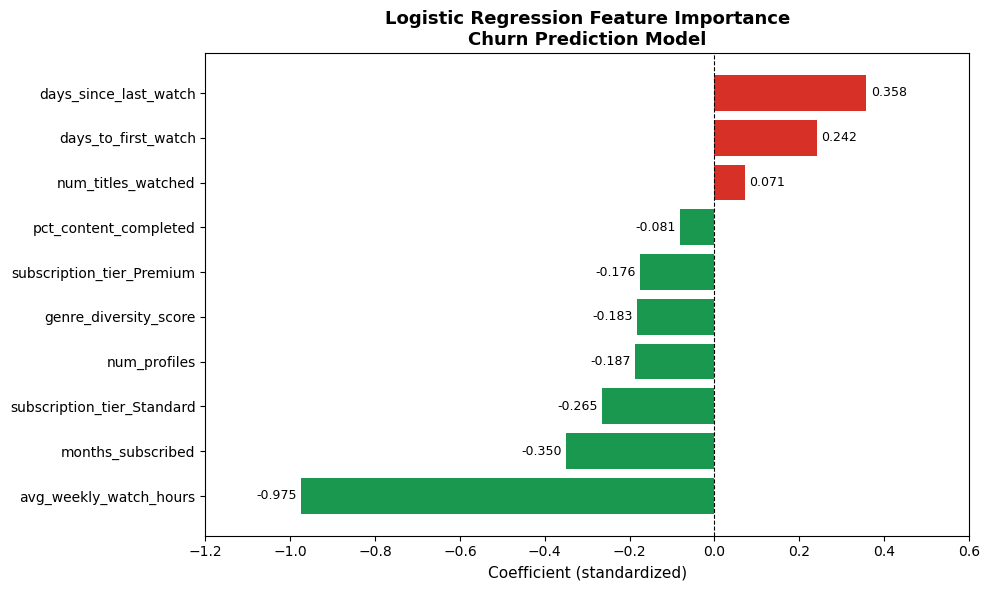

In [8]:
import matplotlib.pyplot as plt

# Sort by coefficient value (not absolute value) for a diverging bar chart
coef_plot = coef_df.sort_values("coefficient")

# Color bars by direction — red for positive (higher churn risk), green for negative (lower risk)
colors = ["#d73027" if c > 0 else "#1a9850" for c in coef_plot["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_plot["feature"], coef_plot["coefficient"], color=colors)

# Add a vertical line at 0 for reference
ax.axvline(x=0, color="black", linewidth=0.8, linestyle="--")

# Label each bar with its coefficient value
for bar, val in zip(bars, coef_plot["coefficient"]):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9
    )

ax.set_xlabel("Coefficient (standardized)", fontsize=11)
ax.set_title("Logistic Regression Feature Importance\nChurn Prediction Model", fontsize=13, fontweight="bold")
ax.set_xlim(-1.2, 0.6)
plt.tight_layout()
plt.show()

In [6]:
# 2 different ways of prediction on test sets
## 1. Gives hard binary prediction using a default threshold of 0.5. Meaning 1 if probability
## is >= 0.5, and 0 if < 0.5.
y_pred = model.predict(X_test_scaled)
## 2. Gives raw probability of churning. This person has a _% chance of churning.
## The idea is to ue these probabilities for ROC/AUC scores. These need the raw probabilities
## rather than the 0.5 cutoff.
## We also would use these probabilities for risk segmentation. Low/Medium/High risk
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
print("=== Model Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

=== Model Performance ===
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1655
           1       0.59      0.13      0.21       345

    accuracy                           0.83      2000
   macro avg       0.72      0.55      0.56      2000
weighted avg       0.80      0.83      0.79      2000

ROC-AUC: 0.797


**Interpreting the classification report**

Precision and Recall:
* $${Precision} = \frac{True Positives}{(True Positives + False Positives)}$$
* $${Recall} = \frac{True Positives}{(True Positives + False Negatives)}$$

**Class 0 (not churned)**
* Precision: 0.84
* How trustworthy are the predictions? 84%.
* Recall: 0.98
* Of everyone that churned, how many did the model catch? 98%.
* Both are high, meaning the model is very good at identifying subscribers who won't churn

**Class 1 (churned)**
* Precision 0.59 - when it predicts "churned", it is right 59% of the time
* Recall 0.13 - it only catches 13% of actual churners.
* Both are low, meaning the model struggles with identifying churners. 

**Important Note:**
- Overall accuracy of 83% is misleading in this situation. A naive model predicting 
  "not churned" for every subscriber would achieve the same score. ROC-AUC of 0.80 is 
  a more meaningful metric, showing the model can genuinely rank subscribers by churn risk.
- Support shows 1,655 non-churners vs 345 churners in the test set. A model predicting 
  "not churned" for all 2,000 subscribers would score 1,655/2,000 = 82.8% accuracy 
  — identical to our model's 83%. This confirms accuracy is not a useful 
  metric here.  
- For a production deployment, the classification threshold could be lowered below 0.5 
  to improve recall on churners at the cost of some precision — since missing a real 
  churner is typically more costly to a business than a false alarm on someone who 
  would have stayed anyway.
